In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

In [3]:
data ={
    'Date': pd.date_range(start='2024-01-01', periods=10, freq='D'),
    'Close': [150,152,153,155,154,156,157,158,159,160]
}

df = pd.DataFrame(data)

df['Date'] = df['Date'].map(pd.Timestamp.toordinal)

print("Stock Price Data: ")
print(df.head())

Stock Price Data: 
     Date  Close
0  738886    150
1  738887    152
2  738888    153
3  738889    155
4  738890    154


In [4]:
X = df[['Date']]
y = df['Close']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [5]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
y_pred

array([159.0862069, 151.6637931])

In [6]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error:", mse)
print("R-squared:", r2)

Mean Squared Error: 0.06023335316288063
R-squared: 0.9950829915785404


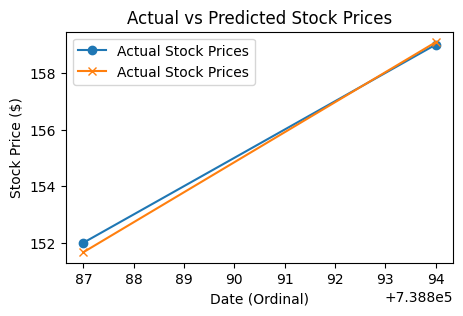

In [7]:
plt.figure(figsize=(5,3))
plt.plot(X_test, y_test, label="Actual Stock Prices", marker='o')
plt.plot(X_test, y_pred, label="Actual Stock Prices", marker='x')
plt.title("Actual vs Predicted Stock Prices")
plt.xlabel("Date (Ordinal)")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.show()


In [8]:
future_date = pd.Timestamp('2024-01-11').toordinal()
future_date = pd.DataFrame({'Date': [future_date]})

future_price = model.predict(future_date)

print("Predicted Stock Price for 2024-01-11:", future_price[0])

Predicted Stock Price for 2024-01-11: 161.20689655165188
